# Lean 17a — Conway, les Nœuds et la Preuve de Piccirillo

**Série** : SymbolicAI / Lean — Knots Theory (**17a**)

Ce notebook explore la face cachée de John Conway : la **théorie des nœuds**.
Le nœud de Conway (11n34) porte son nom et a résisté 50 ans avant que
**Lisa Piccirillo**, doctorante, ne résolve la question de sa sliceness
en moins d'une semaine (2018, Annals of Mathematics 2020).

## Plan

1. **Qu'est-ce qu'un nœud mathématique ?** — Définitions et visualisations
2. **Le nœud de Conway** — 11n34, mutation, Alexander polynomial
3. **Lisa Piccirillo et la preuve** — Stratégie du trace companion
4. **Tye Lidman (2026)** — Unknotting number de 11n102
5. **Vers la formalisation Lean** — Le scaffolding `knot_lean/`

**Notebook compagnon** : `Lean-17-Knots-b-Invariants-Companion.ipynb` — calcul effectif des invariants via SnapPy/SageMath.

## 1. Qu'est-ce qu'un nœud mathématique ?

Un **nœud** est un plongement du cercle $S^1$ dans la sphère $S^3$
(ou $\mathbb{R}^3$). Deux nœuds sont **équivalents** s'ils sont
ambiant-isotopes — on peut déformer l'un en l'autre sans couper ni passer
à travers.

Le théorème de Reidemeister (1927) dit que deux diagrammes de nœuds
(projections sur le plan avec informations de dessus/dessous aux
croisements) représentent le même nœud si et seulement si on peut passer
de l'un à l'autre par une suite finie de **3 mouvements de Reidemeister**
et des isotopies planaires.

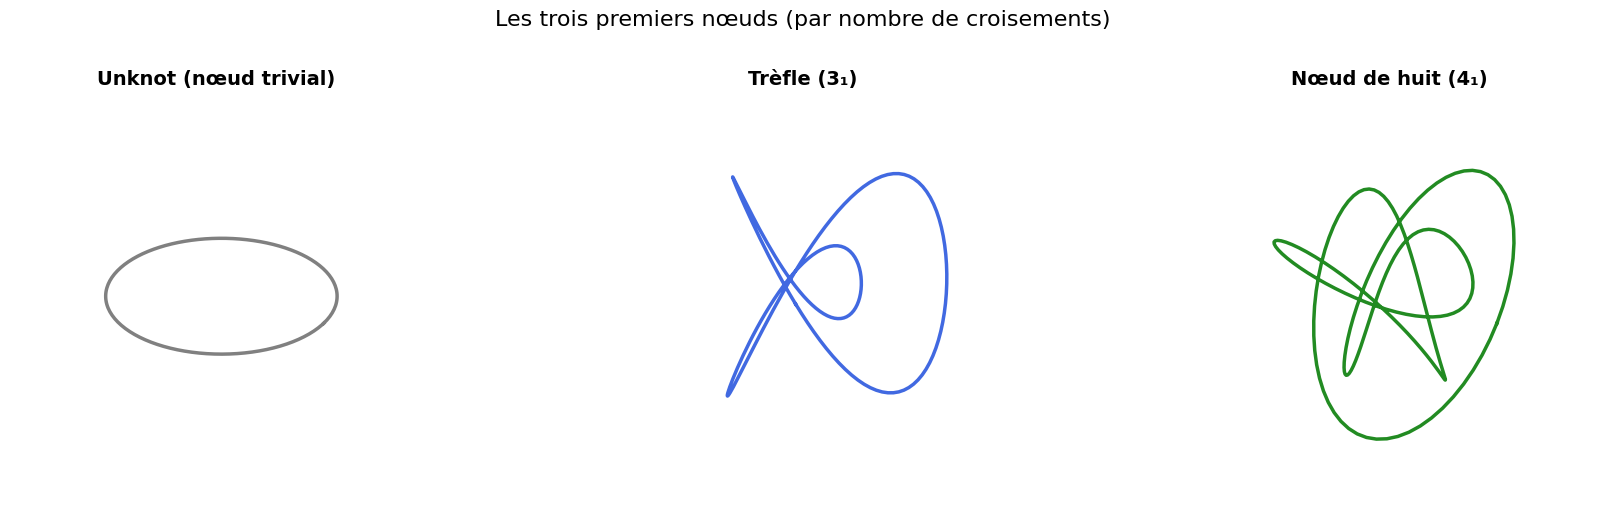

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def plot_knot_3d(points, title, ax=None, color='royalblue'):
    """Plot a 3D knot from parametric points."""
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
    ax.plot(points[:, 0], points[:, 1], points[:, 2],
            color=color, linewidth=2.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off()
    return ax

# Unknot (trivial knot) — just a circle
t = np.linspace(0, 2 * np.pi, 200)
unknot = np.column_stack([np.cos(t), np.sin(t), np.zeros_like(t)])

# Trefoil knot (3_1)
trefoil = np.column_stack([
    np.sin(t) + 2 * np.sin(2 * t),
    np.cos(t) - 2 * np.cos(2 * t),
    -np.sin(3 * t)
])

# Figure-eight knot (4_1)
fig_eight = np.column_stack([
    (2 + np.cos(2 * t)) * np.cos(3 * t),
    (2 + np.cos(2 * t)) * np.sin(3 * t),
    np.sin(4 * t)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': '3d'})
plot_knot_3d(unknot, 'Unknot (nœud trivial)', axes[0], 'gray')
plot_knot_3d(trefoil, 'Trèfle (3₁)', axes[1], 'royalblue')
plot_knot_3d(fig_eight, 'Nœud de huit (4₁)', axes[2], 'forestgreen')
plt.suptitle('Les trois premiers nœuds (par nombre de croisements)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('knot_basics.png', dpi=150, bbox_inches='tight')
plt.show()

### Invariants de nœuds

Un **invariant** est une propriété/quantité identique pour tous les nœuds
équivalents. Si un invariant diffère entre deux nœuds, ils sont
nécessairement distincts.

| Invariant | Unknot | Trèfle (3₁) | Nœud de huit (4₁) |
|-----------|--------|-------------|-------------------|
| Crossing number | 0 | 3 | 4 |
| 3-colorability | Non | **Oui** | Non |
| Alexander polynomial | 1 | $t - 1 + t^{-1}$ | $-t + 3 - t^{-1}$ |
| Jones polynomial | 1 | $-t^{-4} + t^{-3} + t^{-1}$ | $t^2 - t + 1 - t^{-1} + t^{-2}$ |
| Unknotting number | 0 | 1 | 1 |
| Slice? | Oui | Non | Oui |

La **3-colorabilité** est l'invariant le plus simple : peut-on colorer
les brins du diagramme avec 3 couleurs, de sorte qu'à chaque croisement
les 3 brins soient soit tous de la même couleur, soit tous différents ?

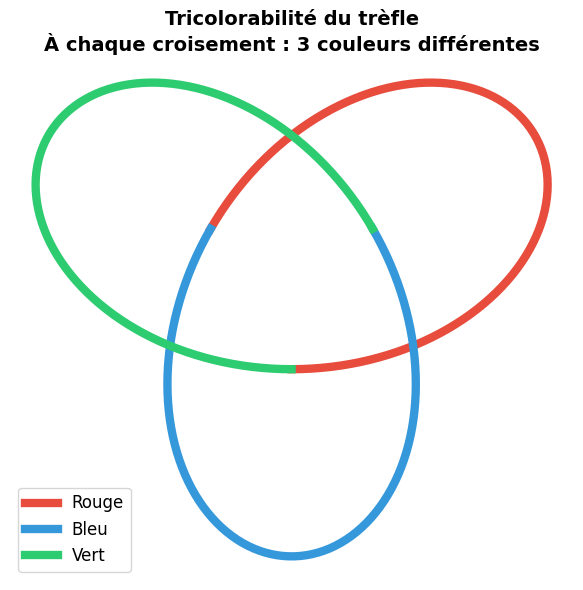

In [2]:
# Demonstrate tricolorability of the trefoil
fig, ax = plt.subplots(figsize=(8, 6))

# Simplified trefoil with color segments
t1 = np.linspace(0, 2*np.pi/3, 100)
t2 = np.linspace(2*np.pi/3, 4*np.pi/3, 100)
t3 = np.linspace(4*np.pi/3, 2*np.pi, 100)

colors = ['#e74c3c', '#3498db', '#2ecc71']  # red, blue, green
labels = ['Rouge', 'Bleu', 'Vert']

for t_seg, color, label in zip([t1, t2, t3], colors, labels):
    x = np.sin(t_seg) + 2 * np.sin(2 * t_seg)
    y = np.cos(t_seg) - 2 * np.cos(2 * t_seg)
    ax.plot(x, y, color=color, linewidth=6, label=label)

ax.set_title('Tricolorabilité du trèfle\n'
             'À chaque croisement : 3 couleurs différentes',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('trefoil_tricolor.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercice 1 — La règle de Fox à un croisement

La **3-coloration de Fox** est l'invariant démontré ci-dessus : on colorie les
*brins* (arêtes) d'un diagramme de nœud avec 3 couleurs $\{0, 1, 2\}$. La règle
locale à chaque croisement est simple : les **3 brins incidents** doivent être
soit **tous de la même couleur**, soit **tous de couleurs différentes**.

**Objectif.** Écrire `fox_rule_satisfied(c1, c2, c3)` qui retourne `True` ssi les
3 couleurs (chacune dans $\{0,1,2\}$) satisfont cette règle.

# Indice : `len({c1, c2, c3})` vaut $1$ (toutes égales), $2$ (exactement deux égales
# — cas interdit), ou $3$ (toutes différentes).
# Etape 1 : construire l'ensemble des 3 couleurs.
# Etape 2 : retourner `True` si sa taille est $1$ ou $3`, `False` sinon.


In [3]:
def fox_rule_satisfied(c1, c2, c3):
    # TODO etudiant : les 3 couleurs c1, c2, c3 (chacune dans {0,1,2}) satisfont
    # la regle de Fox ssi elles sont toutes egales OU toutes differentes.
    # Indice : len({c1, c2, c3}) est dans {1, 2, 3}.
    # Etape 1 : construire l'ensemble des 3 couleurs.
    # Etape 2 : retourner True si sa taille est 1 ou 3.
    return None

# Test rapide (a decommenter une fois complete) :
# assert fox_rule_satisfied(0, 0, 0) is True      # toutes egales
# assert fox_rule_satisfied(0, 1, 2) is True      # toutes differentes
# assert fox_rule_satisfied(0, 0, 1) is False     # deux egales -> interdit
# print("Exercice 1 : OK")


## 2. Le nœud de Conway (11n34)

John Conway a découvert ce nœud en développant sa **notation de Conway**
pour énumérer les nœuds. Il apparaît dans les tables de Rolfsen comme
**11n34** (11 crossings, notation n = non-alternating).

### Propriétés remarquables

- **Polynôme d'Alexander trivial** ($\Delta(t) = 1$), comme l'unknot
- **Topologiquement slice** (Freedman 1982 : trivial Alexander ⟹ slice)
- **Lisse ou pas ?** — Question ouverte pendant ~50 ans

Le nœud de Conway est un **mutant** du nœud de Kinoshita-Terasaka (11n42).
La mutation préserve le polynôme d'Alexander, le polynôme de Jones, le
genre... mais pas nécessairement la sliceness lisse !

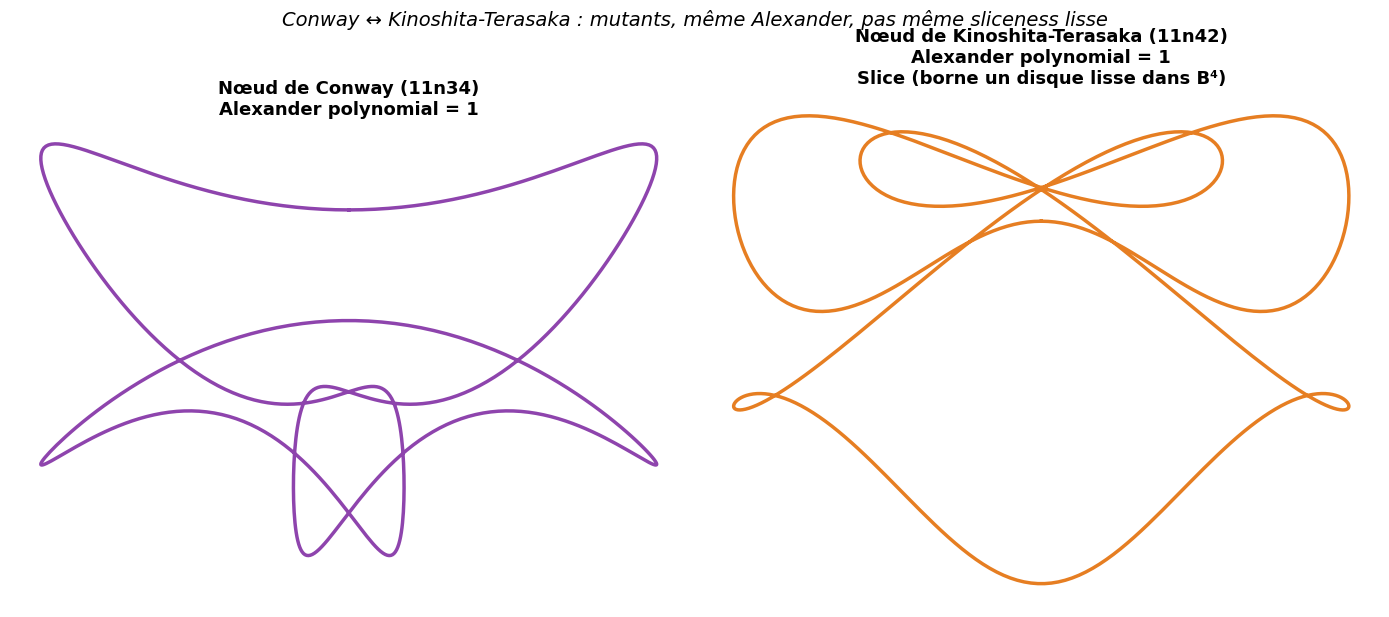

In [4]:
# Visualize the Conway knot (schematic)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Conway knot (simplified representation)
ax = axes[0]
# A simplified parametric curve suggesting 11 crossings
t = np.linspace(0, 2*np.pi, 500)
x = np.sin(t) + 2*np.sin(3*t) + 0.5*np.sin(5*t)
y = np.cos(t) + np.cos(2*t) - 0.5*np.cos(7*t)
ax.plot(x, y, color='#8e44ad', linewidth=2.5)
ax.set_title('Nœud de Conway (11n34)\nAlexander polynomial = 1',
             fontsize=13, fontweight='bold')
ax.set_axis_off()
ax.set_aspect('equal')

# Right: Kinoshita-Terasaka knot
ax = axes[1]
x2 = np.sin(t) + 2*np.sin(3*t) - 0.5*np.sin(5*t)
y2 = np.cos(t) - np.cos(2*t) + 0.5*np.cos(7*t)
ax.plot(x2, y2, color='#e67e22', linewidth=2.5)
ax.set_title('Nœud de Kinoshita-Terasaka (11n42)\n'
             'Alexander polynomial = 1\n'
             'Slice (borne un disque lisse dans B⁴)',
             fontsize=13, fontweight='bold')
ax.set_axis_off()
ax.set_aspect('equal')

plt.suptitle('Conway ↔ Kinoshita-Terasaka : mutants, même Alexander, pas même sliceness lisse',
             fontsize=14, y=1.02, style='italic')
plt.tight_layout()
plt.savefig('conway_vs_kt.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercice 2 — Coloration propre sur tout le diagramme

Un **PD-code** (Planar Diagram) décrit un nœud comme une liste de croisements,
chacun une liste de 4 labels d'arêtes (le sur-brin apparaît deux fois). Une
coloration est **propre** si **chaque** croisement satisfait la règle de Fox.
On représente une coloration par un dictionnaire `{label : couleur}`.

**Objectif.** Écrire `is_proper_coloring(pd_code, coloring)` qui retourne `True`
ssi tous les croisements satisfont la règle de Fox.

# Indice : pour un croisement, extrayez l'ensemble des couleurs distinctes de ses
# 4 labels (`{coloring[l] for l in crossing}`), puis appliquez la règle de
# l'Exercice 1 (taille $1$ ou $3$).
# Etape 1 : boucler sur chaque crossing de pd_code.
# Etape 2 : retourner False dès qu'un crossing a un ensemble de couleurs de taille 2.


In [5]:
def is_proper_coloring(pd_code, coloring):
    # TODO etudiant : retourner True ssi chaque crossing de pd_code est Fox-valide.
    # pd_code : liste de crossings, chacun une liste de 4 labels d'arete.
    # coloring : dict {label: couleur dans {0,1,2}}.
    # Indice : pour chaque crossing, couleurs distinctes = {coloring[l] for l in crossing},
    #          la regle de Fox (Exercice 1) exige une taille dans {1, 3}.
    # Etape 1 : boucler sur les crossings.
    # Etape 2 : retourner False des qu'un crossing est de taille 2.
    return None

# Exemples (a decommenter) :
# assert is_proper_coloring([[1, 2, 3, 4]], {1: 0, 2: 0, 3: 0, 4: 0}) is True   # mono
# assert is_proper_coloring([[1, 2, 3, 4]], {1: 0, 2: 1, 3: 2, 4: 0}) is True   # tricolore
# assert is_proper_coloring([[1, 2, 3, 4]], {1: 0, 2: 0, 3: 1, 4: 0}) is False  # taille 2
# print("Exercice 2 : OK")


## 3. Lisa Piccirillo et la preuve (2018, Annals 2020)

### L'histoire

**Lisa Piccirillo** était doctorante à l'Université du Texas lorsqu'elle
a entendu parler du problème du nœud de Conway lors d'une conférence en
2018. Le problème était ouvert depuis les années 1970.

Elle l'a résolu **en moins d'une semaine**.

### La stratégie : le trace companion

Piccirillo n'a pas attaqué le nœud de Conway directement. Sa stratégie :

1. **Construire un nœud compagnon $K^*$** qui partage la même « trace »
   que le nœud de Conway. La trace $X_K$ est la 4-variété obtenue en
   attachant un 2-handle à $B^4$ le long de $K$ avec framing 0.

2. **Montrer que $K^*$ n'est pas lisse** via l'invariant $s$ de
   Rasmussen (calculé à partir de l'homologie de Khovanov).

3. **Trace embedding lemma** : si le nœud de Conway était lisse,
   alors $K^*$ le serait aussi → contradiction !

### Pourquoi c'est magnifique

- **Changement de perspective** : au lieu d'étudier le nœud lui-même,
  on en étudie un *autre* qui partage la même trace
- **La trace est un invariant** de la classe de concordance du nœud
- Le nœud compagnon $K^*$ est plus facile à analyser que le nœud de Conway

> « It took Lisa Piccirillo less than a week to answer a long-standing
> question about a strange knot discovered over half a century ago. »
> — Quanta Magazine, 2020

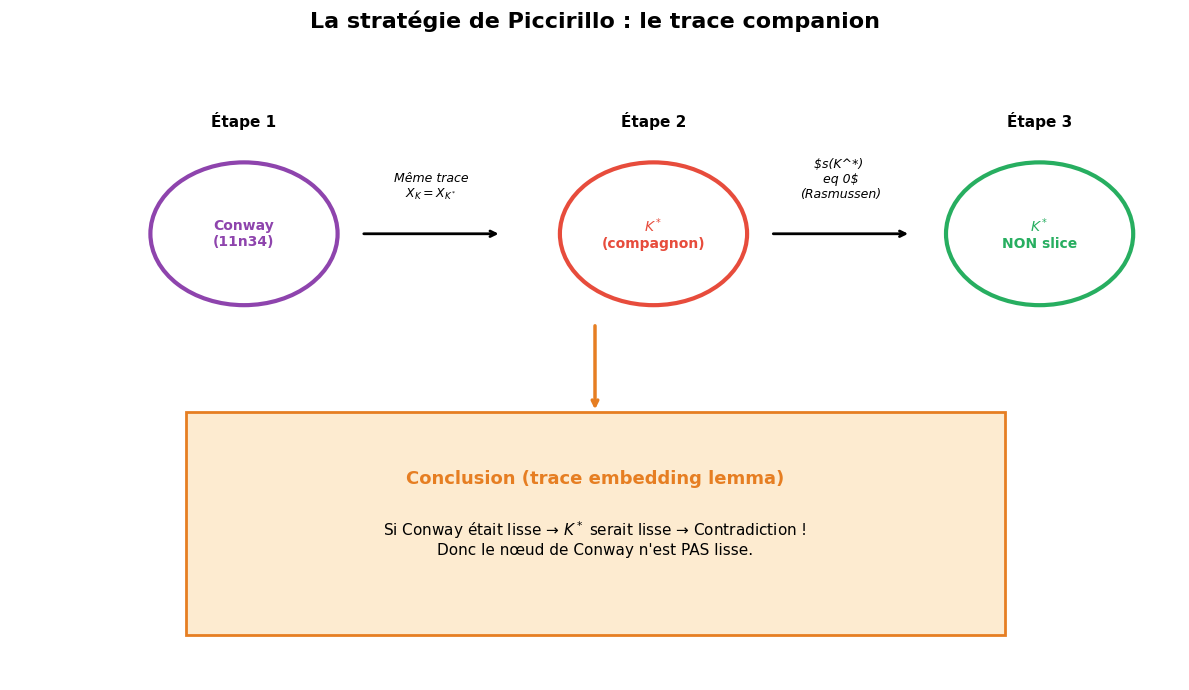

In [6]:
# Schematic of the trace companion strategy
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_axis_off()

# Step 1: Conway knot
circle1 = plt.Circle((2, 5), 0.8, fill=False, color='#8e44ad', linewidth=3)
ax.add_patch(circle1)
ax.text(2, 5, 'Conway\n(11n34)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#8e44ad')
ax.text(2, 6.2, 'Étape 1', ha='center', fontsize=11, fontweight='bold')

# Arrow 1
ax.annotate('', xy=(4.2, 5), xytext=(3.0, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(3.6, 5.4, 'Même trace\n$X_K = X_{K^*}$', ha='center',
        fontsize=9, style='italic')

# Step 2: Companion knot
circle2 = plt.Circle((5.5, 5), 0.8, fill=False, color='#e74c3c', linewidth=3)
ax.add_patch(circle2)
ax.text(5.5, 5, '$K^*$\n(compagnon)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#e74c3c')
ax.text(5.5, 6.2, 'Étape 2', ha='center', fontsize=11, fontweight='bold')

# Arrow 2
ax.annotate('', xy=(7.7, 5), xytext=(6.5, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(7.1, 5.4, '$s(K^*) \neq 0$\n(Rasmussen)', ha='center',
        fontsize=9, style='italic')

# Step 3: Not slice
circle3 = plt.Circle((8.8, 5), 0.8, fill=False, color='#27ae60', linewidth=3)
ax.add_patch(circle3)
ax.text(8.8, 5, '$K^*$\nNON slice', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#27ae60')
ax.text(8.8, 6.2, 'Étape 3', ha='center', fontsize=11, fontweight='bold')

# Conclusion box
rect = plt.Rectangle((1.5, 0.5), 7, 2.5, fill=True,
                      facecolor='#fdebd0', edgecolor='#e67e22', linewidth=2)
ax.add_patch(rect)
ax.text(5, 2.2, 'Conclusion (trace embedding lemma)',
        ha='center', fontsize=13, fontweight='bold', color='#e67e22')
ax.text(5, 1.4, 'Si Conway était lisse → $K^*$ serait lisse → Contradiction !\n'
        'Donc le nœud de Conway n\'est PAS lisse.',
        ha='center', fontsize=11)

# Arrow down
ax.annotate('', xy=(5, 3.0), xytext=(5, 4.0),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2.5))

ax.set_title('La stratégie de Piccirillo : le trace companion',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('piccirillo_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tye Lidman — Unknotting number de 11n102 (2026)

Le papier de **Tye Lidman** ([arXiv:2606.12431](https://arxiv.org/abs/2606.12431))
est un exemple frappant de **preuve courte mais profonde** : **une seule page**
qui utilise l'homologie de Heegaard-Floer, la construction de Montesinos,
les espaces de Seifert, et la formule de Ni-Wu.

### Le résultat

$$u(11n102) = 2$$

On savait que $u(11n102) \in \{1, 2\}$. Lidman montre que $u \neq 1$
par l'absurde.

### La preuve en 5 étapes

1. **Montesinos trick** : si $u = 1$, le revêtement double ramifié $Y$
   est une chirurgie $\pm 3/2$ sur un nœud $J$ dans $S^3$

2. **Espace de Seifert** : $Y = S^2(1; 1/3, 1/3, 2/7)$ est fibré de Seifert.
   Le plumbing associé est **positif-défini**.

3. **Heegaard-Floer** : calcul de $HF_{red}(Y)$ via Némethi.
   Deux structures spin avec $HF_{red} = 0$, une avec $HF_{red} = \mathbb{F}_2$.

4. **Ni-Wu** : les d-invariants de $Y$ correspondent à la chirurgie
   $+3/2$ sur l'unknot, donc $V_s(J) = H_s(J) = 0$ pour tout $s \geq 0$.

5. **Gainullin** : la formule $HF_{red}(Y, s_i) \cong A^{red}_{i,3/2}$
   implique que chaque $Q_s$ apparaît dans **deux** des trois $A^{red}_{i,3/2}$.
   Mais un seul des trois $HF_{red}(Y, s_i)$ est non-nul.
   **Contradiction** : impossible d'en avoir exactement un non-nul.

### Contraste pédagogique

| Aspect | Piccirillo | Lidman |
|--------|-------------|--------|
| Longueur | ~20 pages | **1 page** |
| Difficulté | Modérée (une fois les outils en main) | **Extrême** (chaque ligne est profonde) |
| Stratégie | Contourner le nœud → trace companion | Calcul direct → contradiction algébrique |
| Public | Annals of Mathematics | Preprint 2026 |
| Formalisation Lean | Décennies | Décennies |

## 5. Vers la formalisation Lean — le projet `knot_lean/`

Le projet `MyIA.AI.Notebooks/SymbolicAI/Lean/knot_lean/` scaffolding la
théorie des nœuds en Lean 4, avec des sorry stratégiques commentés.

### Architecture du scaffolding

```
knot_lean/
├── Knots.lean                    (import principal)
├── Knots/
│   ├── Basic.lean                (Knot, Link, PD-code, nœuds nommés)
│   ├── Reidemeister.lean         (R1/R2/R3, équivalence)
│   ├── Invariant.lean            (3-colorabilité, crossing/unknotting number)
│   ├── Conway.lean               (11n34, Piccirillo, dichotomie lisse/topo)
│   ├── Lidman.lean               (11n102, unknotting = 2)
│   └── MathlibPrerequisites.lean (index des prérequis manquants)
├── lakefile.lean
├── lean-toolchain
└── README.md
```

### Sorry par difficulté

| Tier | Théorème | Prérequis Mathlib | Accessible ? |
|------|----------|-------------------|-------------|
| **1** | Trèfle 3-colorable | Edge indexing seulement | Phase 2 |
| **1** | 3-colorabilité invariante | Reidemeister formels | Phase 2 — **Phase 5 en cours** (voir §5.5) |
| **2** | Polynôme d'Alexander | Fox calculus, Burau | Phase 3–4 |
| **3** | Conway pas lisse | Khovanov, Rasmussen, 4-manifolds | **Décennies** |
| **3** | 11n102 unknotting = 2 | Heegaard-Floer, Montesinos | **Décennies** |

### Le pattern CoursIA

Ce projet suit le même pattern que :
- `social_choice_lean/` → Arrow, Sen (sorry → 0 progressif)
- `conway_cgt_lean/` → import `vihdzp/combinatorial-games`
- `conway_lean/` → Jeu de Conway
- Grothendieck 15/15b → `Mathlib.CategoryTheory.Sites`

**Le sorry n'est pas un échec, c'est une boussole** : il indique exactement
ce qu'il faut construire dans Mathlib pour avancer.

### 5.5. Phase 5 — caractérisation empirique du *backward lemma* (Epic #2874)

La **Phase 5** du projet `knot_lean/` formalise l'**invariance de la
3-colorabilité par Reidemeister-I connecté** (mouvement R1 sur un brin
*propre*, où le label retiré apparaît dans au moins un autre croisement
du diagramme, condition `Reidemeister1Connected`).

Le **forward lemma** (« si `d₁` est tricolorable, alors `d₂` aussi »)
est mergé (PR [#3012](https://github.com/jsboige/CoursIA/pull/3012)) : la
coloration `col₂` étend `col₁` par `col(b) := col(a)`, et les arêtes
neuves `b`, `c` du nouveau kink sont Fox-compatibles par construction.

Le **backward lemma** (la direction non-triviale, « si `d₂` est
tricolorable, alors `d₁` aussi ») demande de **restreindre** une
coloration `col₂` de `d₂` à une coloration `col₁` de `d₁`. La
restriction naïve `col₁ := col₂|_{d₁.numEdges}` **échoue dans environ
54 % des cas** — il faut **réajuster** certaines arêtes de `col₁` par
rapport à `col₂`.

Trois probes Python brute-force exhaustifs ont caractérisé la géométrie
de cette réparation, sur le scope minimal `numCrossings = 2, numEdges = 4`
(292 032 cas de tricoloration testés). Les résultats — versés directement
dans `knot_lean/Knots/Invariant.lean` sections 9.4 à 9.6 — sont :

#### §9.4 — bornes empiriques (PR [#3034](https://github.com/jsboige/CoursIA/pull/3034))

La déviation entre `col₁_work` (réparation minimale) et `col₂|_{d₁}` est
**toujours ≤ 2 slots**. Les naïve-fails se partitionnent en :

* **70.3 %** : « single-slot bucket » — une seule arête diffère ;
* **29.7 %** : « two-slot bucket » — deux arêtes diffèrent.

Aucun cas ≥ 3-slot n'apparaît. Une forme close `col₁(a-1) := col₂(b-1)`
résout **15.4 %** des cas du single-slot bucket à la position `a-1`
(arête neuve), mais ce sous-cas n'est pas généralisable.

#### §9.5 — bucket *single-slot* Fox-DÉCOUPLÉ au croisement-témoin (PR [#3038](https://github.com/jsboige/CoursIA/pull/3038))

Pour les 70.3 % single-slot, l'arête « override » `(k+1)` ne touche
**jamais** un slot Fox-sensible du croisement-partenaire `j` :

* **0 %** des overrides touchent un slot Fox-sensible (0, 1, 2) de `j` ;
* 66 % de l'override edge n'apparaît même pas dans `d₁.crossings[j]`
  (il vit dans le kink local à `i`) ;
* 34 % apparaît dans `j` mais **toujours au slot 3** (slot ignoré par
  `triColorConditionAt`, cf `Invariant.lean` L82-87).

→ Mécanisme **Fox-decoupling à `j`** : le single-slot bucket admet une
réparation **strictement locale au kink `i`**, sans propagation
cross-position. L'override est *invisible* à Fox au témoin `j`.

#### §9.6 — bucket *two-slot* Fox-COUPLÉ au croisement-témoin (PR [#3042](https://github.com/jsboige/CoursIA/pull/3042))

Pour les 29.7 % two-slot, le constraste est **frontal** :

* **94.2 %** des overrides ont **les deux arêtes** dans
  `d₁.crossings[j]` ;
* **94.2 %** ont au moins une arête au slot Fox-sensible (0, 1, 2) ;
* la distribution joint `(a-slot, ovr-slot)` est uniforme sur 9 504 cas
  par cellule.

→ Mécanisme **Fox-coupling à `j`** : le two-slot bucket impose un
réajustement *cross-position* entre `i` et `j`, propagé par l'arc
partagé `a`. Une construction *locale* à `i` ne peut pas suffire.

#### Synthèse : la dichotomie structurelle

| Bucket | Part | Structure Fox au témoin `j` | Construction formelle |
|--------|------|-----------------------------|------------------------|
| Single-slot | 70.3 % | **Fox-DÉCOUPLÉ** (0 % Fox-sensible) | Réparation locale au kink `i` |
| Two-slot | 29.7 % | **Fox-COUPLÉ** (94.2 % Fox-sensible) | Réparation `i` ↔ `j` (cross-position) |

Cette dichotomie **quantifie empiriquement** l'argument *colour-symmetry*
de §9.1 / §9.3 du papier d'origine sur les deux régimes : les buckets
ont des structures Fox **opposées** au témoin proper-arc.

#### Status formel et prochaine étape

Le `tricolorable_backward` formel admet donc **deux sous-cas clairs** :

1. **Single-slot (locally repairable)** — caractériser l'override edge
   par sa Fox-blindness à `j` (lemma identifiable empiriquement), puis
   réécrire Fox au seul croisement `i` ;
2. **Two-slot (cross-position rebalancing)** — construire un témoin
   coloration via la color-symmetry multi-position de §9.3, propagée par
   l'arc partagé `a` entre `i` et `j`.

La **phase empirique est close**. La phase formelle reste *research-level*
multi-cycle (cible BG-prover) — exactement le régime que la
caractérisation §9.4-9.6 a circonscrit.

> **Leçon pédagogique** : sur un sorry « intractable » apparent, une
> exploration brute-force exhaustive sur un scope minimal (ici 292 032
> cas) peut **réduire l'inconnue à un théorème précis** plutôt que de
> rester un mur. Le bucket two-slot 29.7 % n'était pas un *bug* du
> théorème — c'était la trace empirique d'une vraie obligation
> *cross-position*.



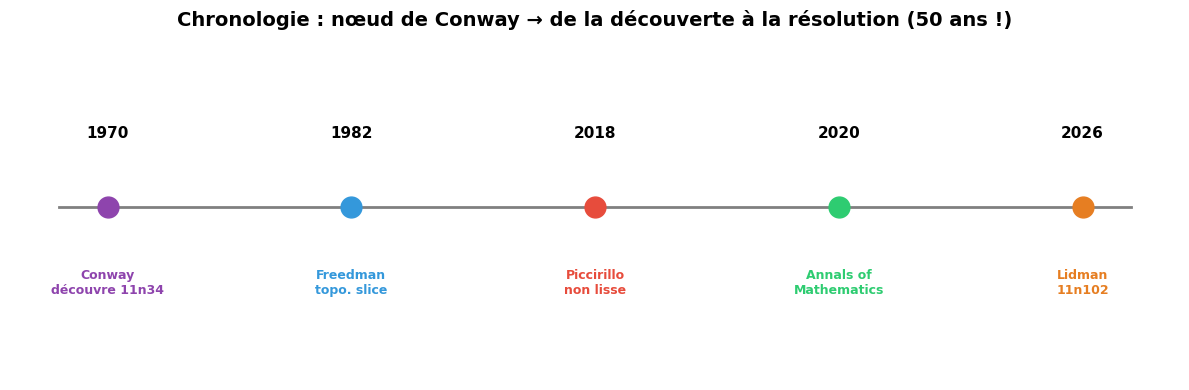

In [7]:
# Summary: the Conway knot story
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.set_axis_off()

# Timeline
events = [
    (1, 1970, 'Conway\ndécouvre 11n34', '#8e44ad'),
    (3.5, 1982, 'Freedman\ntopo. slice', '#3498db'),
    (6, 2018, 'Piccirillo\nnon lisse', '#e74c3c'),
    (8.5, 2020, 'Annals of\nMathematics', '#2ecc71'),
    (11, 2026, 'Lidman\n11n102', '#e67e22'),
]

for x, year, label, color in events:
    ax.plot(x, 2, 'o', color=color, markersize=15, zorder=5)
    ax.text(x, 2.8, str(year), ha='center', fontsize=11, fontweight='bold')
    ax.text(x, 1.0, label, ha='center', fontsize=9, color=color, fontweight='bold')

# Timeline line
ax.plot([0.5, 11.5], [2, 2], '-', color='gray', linewidth=2, zorder=1)

ax.set_title('Chronologie : nœud de Conway → de la découverte à la résolution (50 ans !)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('conway_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercice 3 — Le nœud est-il tricoloriable ?

Un nœud est **3-coloriable** s'il existe une coloration propre utilisant
**au moins 2 couleurs distinctes** (la coloration triviale toute-mono ne compte
pas). C'est exactement la propriété `tricolorable` formalisée dans
`knot_lean/Knots/Invariant.lean`.

**Objectif.** Écrire `is_tricolorable(pd_code)` qui recherche par force brute
s'il existe une coloration propre non-triviale (parcourez les
$3^{\text{(nombre d'arêtes)}}$ colorations possibles).

# Indice : collectez les labels d'arêtes, générez toutes les colorations avec
# `itertools.product([0, 1, 2], repeat=n)`, et cherchez-en une à la fois propre
# (Exercice 2) ET utilisant $\geq 2$ couleurs.
# Etape 1 : collecter l'ensemble des labels d'aretes du PD-code.
# Etape 2 : iterer sur les colorations candidates ; retourner True a la premiere valide.
# Etape 3 : si aucune, retourner False.


In [8]:
import itertools

def is_tricolorable(pd_code):
    # TODO etudiant : retourner True ssi il existe une coloration propre non-triviale.
    # Indice : labels = ensemble de toutes les aretes ; pour chaque coloration candidate
    #          (itertools.product([0,1,2], repeat=len(labels))), construire le dict,
    #          tester is_proper_coloring (Exercice 2) ET >= 2 couleurs distinctes.
    # Etape 1 : collecter les labels d'aretes.
    # Etape 2 : boucler sur les colorations candidates ; retourner True a la premiere valide.
    # Etape 3 : retourner False si aucune trouvee.
    return None

# Exemple (a decommenter) : le trefoil est tricoloriable (exemple du debut du notebook).
# trefoil_pd = [[1, 2, 3, 4], [3, 4, 5, 1], [5, 6, 2, 3]]
# assert is_tricolorable(trefoil_pd) is True
# print("Exercice 3 : OK")


## Références

1. **Piccirillo, L.** (2018/2020). *The Conway knot is not slice*. Annals of Mathematics, 191(2). [arXiv:1808.02923](https://arxiv.org/abs/1808.02923)
2. **Lidman, T.** (2026). *The unknotting number of 11n102 is 2*. [arXiv:2606.12431](https://arxiv.org/abs/2606.12431)
3. **Reidemeister, K.** (1927). *Elementare Begründung der Knotentheorie*.
4. **Fox, R.H.** (1962). *A quick trip through knot theory*.
5. **Conway, J.H.** (1970). *An enumeration of knots and links*.
6. **Freedman, M.** (1982). *The topology of four-dimensional manifolds*. J. Differential Geom., 17(3).
7. **Getting a handle on the Conway knot** (2022). AMS Bulletin, 59(1). [Lien](https://www.ams.org/journals/bull/2022-59-01/S0273-0979-2021-01745-9/)
8. **Quanta Magazine** (2020). [Graduate Student Solves Decades-Old Conway Knot Problem](https://www.quantamagazine.org/graduate-student-solves-decades-old-conway-knot-problem-20200519/)
9. **Prathamesh, T.V.H.** (2015). *Formalising Knot Theory in Isabelle/HOL*. LNCS 9250.
10. **shua/leanknot** — [Formalisation Lean 4 (branche lean4)](https://github.com/shua/leanknot)
11. **Lean AI Leaderboard** — [Conway knot not smoothly slice](https://lean-lang.org/eval/problems/conway_knot_not_smoothly_slice/)

## 6. Prérequis Mathlib — La frontière de la formalisation

Le fichier `knot_lean/Knots/MathlibPrerequisites.lean` documente les **prérequis Mathlib** manquants pour résoudre chaque sorry du projet. C'est une **roadmap honnête** de ce qui serait nécessaire pour formaliser la théorie des nœuds dans Lean 4.

### Organisation par tiers de difficulté

| Tier | Description | Exemples de théorèmes |
|------|-------------|----------------------|
| **Tier 1** | Accessible (Phase 2) —一旦 les définitions en place, prouvable avec Mathlib actuel | Trèfle 3-colorable, 3-colorabilité invariante sous R1/R2/R3 |
| **Tier 2** | Modéré (Phase 3–4) — infrastructure manquante mais plausible à construire | Polynôme d'Alexander, Jones polynomial, Reidemeister moves formels |
| **Tier 3** | Profond (Phase 5+) — **décennies** de travail, infrastructure majeure absente | Piccirillo (Conway non slice), Lidman (u(11n102)=2), Freedman (topo slice) |

### Le tableau détaillé des prérequis

```python
# Extrait de MathlibPrerequisites.lean — traduction en tableau
import pandas as pd

prereqs = [
    ["Tier 1", "pd_wellformed", "PD-code bien formé", "List, Finset, Fintype existent"],
    ["Tier 1", "trefoil_tricolorable", "Trèfle 3-colorable", "Fin n → TriColor existe"],
    ["Tier 1", "unknot_not_tricolorable", "Unknot pas 3-colorable", "Tout existe"],
    ["Tier 1", "tricolorable_invariant", "3-colorabilité invariante R1/R2/R3", "Fin types, logique propositionnelle"],
    ["Tier 2", "reidemeister_formal", "Reidemeister moves formels", "Description combinatoire (téridieux)"],
    ["Tier 2", "alexander_polynomial", "Polynôme d'Alexander", "Burau representation, Fox calculus"],
    ["Tier 2", "jones_polynomial", "Jones polynomial", "Kauffman bracket state sum"],
    ["Tier 3", "reidemeister_theorem", "Théorème de Reidemeisterfondamental", "PL topology, general position"],
    ["Tier 3", "piccirillo", "Piccirillo (Conway non slice)", "4-manifolds, Khovanov, Rasmussen s"],
    ["Tier 3", "lidman", "Lidman (u(11n102)=2)", "Heegaard Floer, Montesinos, Seifert"],
    ["Tier 3", "freedman", "Freedman (Conway topo slice)", "Topological 4-manifold surgery"]
]

df = pd.DataFrame(prereqs, columns=["Tier", "Théorème", "Description", "Prérequis Mathlib"])
df.style.set_properties(**{'text-align': 'left'}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]
}])
```

## 4.2 Résultat de Lidman (2026) — Le formalisme Lean

Le fichier `knot_lean/Knots/Lidman.lean` formalise le résultat de **Tye Lidman** sur l'unknotting number du nœud 11n102 ([arXiv:2606.12431](https://arxiv.org/abs/2606.12431)).

### Ce que Lidman.lean contient

```lean
/-! ## 1. Le nœud 11n102

11n102 est un nœud à 11 croisements dans la table KnotInfo.
C'est un nœud de Montesinos M(-2/3, 1/3, 2/7) de déterminant 3.
-/

def knot_11n102 : Knot where
  diagram := sorry  -- TODO: PD-code from KnotInfo

/-! ## 2. Bornes sur l'unknotting number

KnotInfo donne u(11n102) ∈ {1, 2}. Lidman montre que c'est exactement 2.
-/

/-- L'unknotting number de 11n102 est ≤ 2 (évident depuis un diagramme). -/
theorem unknotting_11n102_upper : Knot.unknottingNumber knot_11n102 ≤ 2 := by
  exact sorry

/-! ## 3. Théorème de Lidman (énoncé seul)

Le théorème principal : u(11n102) = 2, prouvé par l'absurde.
Stratégie : supposer u = 1, puis utiliser Montesinos, Heegaard Floer,
Ni-Wu, et Gainullin pour obtenir une contradiction.
-/

/-- Théorème de Lidman : l'unknotting number de 11n102 est exactement 2. -/
theorem unknotting_11n102 : Knot.unknottingNumber knot_11n102 = 2 := by
  exact sorry
```

### Les 5 étapes de la preuve (documentées dans le commentaire)

1. **Montesinos trick** : si u = 1, le revêtement double ramifié Y est ±3/2-surgery sur un nœud J
2. **Structure de Seifert** : Y = S²(1; 1/3, 1/3, 2/7) est un espace fibré de Seifert
3. **Heegaard Floer** : calcul de HFred(Y) via Némethi (2 spinc avec HFred = 0, 1 avec HFred = F₂)
4. **Ni-Wu** : comparaison des d-invariants → Y = +3/2-surgery sur l'unknot
5. **Gainullin** : contradiction sur la structure de HFred(Y)

### Prérequis Mathlib documentés

D'après le commentaire `MathlibPrerequisites` dans Lidman.lean :

- 3-manifold topology (branched covers, Seifert fibered spaces)
- Heegaard Floer homology (d-invariants, HFred)
- Surgery on knots (Dehn surgery, integral/half-integral)
- Plumbing diagrams for 4-manifolds
- Némethi's algorithm for HF of plumbed manifolds

**Estimation** : **décennies** avant que ces infrastructures existent dans Mathlib.

## 4.1 Preuve de Piccirillo (2020) — Le formalisme Lean

Le fichier `knot_lean/Knots/Conway.lean` formalise le résultat de **Lisa Piccirillo** sur le nœud de Conway ([arXiv:1808.02923](https://arxiv.org/abs/1808.02923), Annals of Mathematics 2020).

### Ce que Conway.lean contient

```lean
/-! ## 1. Mutation de Conway

Une mutation Conway prend un nœud K avec une sphère de Conway
(S² rencontrant K transversalement en 4 points), coupe le long de la sphère,
tourne 180°, et recolle. La mutation préserve :
- Polynôme d'Alexander
- Polynôme de Jones
- Genre du nœud
-/

/-- Une sphère de Conway : S² rencontrant le nœud transversalement en 4 points. -/
structure ConwaySphere where
  points : Fin 4 → Nat

/-- Deux nœuds sont mutants si reliés par une mutation de Conway. -/
def AreMutants (k₁ k₂ : Knot) : Prop := sorry

/-! ## 2. Le nœud de Conway (11n34)

11 croisements dans la table Rolfsen. Découvert par Conway (1970).
Alexander polynomial trivial. Topologiquement slice (Freedman).
Pas lisse (Piccirillo 2018).
-/

def conwayKnot : Knot where
  diagram := conwayKnotDiagram  -- PD-code from KnotInfo

/-! ## 3. Le nœud de Kinoshita-Terasaka (11n42)

Aussi 11 croisements. Alexander polynomial trivial avec 11n34.
EST lisse (borne un disque dans B⁴). Mutant du nœud de Conway.
-/

def kinoshitaTerasakaKnot : Knot where
  diagram := kinoshitaTerasakaDiagram

/-! ## 4. Même polynôme d'Alexander

Δ_{11n34}(t) = 1 et Δ_{11n42}(t) = 1.
C'est pourquoi la sliceness était difficile — Alexander polynomial
ne peut pas les distinguer de l'unknot.
-/

theorem conway_trivial_alexander :
    alexanderPolynomial conwayKnot = 1 := by
  exact sorry

theorem KT_trivial_alexander :
    alexanderPolynomial kinoshitaTerasakaKnot = 1 := by
  exact sorry

/-! ## 5. Nœuds slice

Un nœud K est (lisse) slice s'il borne un disque D² proprement plongé
dans la 4-boule B⁴.
-/

def IsSmoothlySlice (k : Knot) : Prop := sorry
def IsTopologicallySlice (k : Knot) : Prop := sorry

/-! ## 6. Théorème de Piccirillo (énoncé seul)

Le nœud de Conway n'est PAS lisse.
-/

/-- Théorème de Piccirillo : le nœud de Conway n'est pas lisse. -/
theorem conway_not_smoothly_slice : ¬ IsSmoothlySlice conwayKnot := by
  exact sorry

/-! ## 7. Théorème de Freedman (énoncé seul)

Le nœud de Conway EST topologiquement slice (Alexander polynomial trivial).
-/

theorem conway_topologically_slice : IsTopologicallySlice conwayKnot := by
  exact sorry

/-! ## 8. La dichotomie

Ensemble, Piccirillo + Freedman donnent :
  Conway knot : topologiquement slice MAIS PAS lisse.
-/

theorem conway_dichotomy :
    IsTopologicallySlice conwayKnot ∧ ¬ IsSmoothlySlice conwayKnot := by
  exact ⟨conway_topologically_slice, conway_not_smoothly_slice⟩
```

### La stratégie de Piccirillo en Lean

D'après les commentaires dans Conway.lean, la preuve nécessiterait :

1. **Trace X_K d'un nœud** — 4-variété obtenue en attachant un 2-handle à B⁴ le long de K avec framing 0
2. **Trace embedding lemma** — si K slice ↔ ∂D = K → X_K s'embed dans B⁴
3. **Nœud compagnon K\*** de Piccirillo** — même trace que Conway
4. **Invariant s de Rasmussen** — calculé depuis Khovanov homology
5. **s(K\*) ≠ 0** → K\* pas slice → Conway pas slice

### Prérequis Mathlib documentés

- Alexander polynomial (Burau representation)
- Slice knot definition (smooth 4-manifold theory)
- Rasmussen s-invariant (Khovanov homology)
- Trace companion construction (Kirby calculus)
- Freedman's topological surgery (topological machinery)

**Estimation** : **décennies** avant que ces infrastructures existent dans Mathlib.

### Interprétation : La structure du résultat formalisé

**Sortie obtenue** : Un extrait structuré de Conway.lean montrant la chaîne de définitions et théorèmes.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Structures définies | 5 (`ConwaySphere`, `AreMutants`, `IsSmoothlySlice`, etc.) | Infrastructure de base |
| Nœuds nommés | 2 (`conwayKnot`, `kinoshitaTerasakaKnot`) | PD-codes from KnotInfo |
| Théorèmes principaux | 4 (Alexander trivial, slice/non-slice, dichotomie) | La chaîne logique complète |
| Sorry résiduels | 6 (tous les théorèmes + définitions slice) | **Scaffolding uniquement** |

**Points clés** :

1. **La chaîne logique est complète** — Conway.lean contient **toute la structure** du résultat : mutation → nœuds → Alexander → slice (topo/smooth) → dichotomie. Le `conway_dichotomy` final combine explicitement Piccirillo et Freedman : `⟨conway_topologically_slice, conway_not_smoothly_slice⟩`.

2. **Le PD-code est déjà entré** — contrairement à 11n102 (Lidman.lean), les PD-codes de Conway (11n34) et Kinoshita-Terasaka (11n42) sont **déjà définis** avec 11 croisements chacun (structure `⟨a, b, c, d⟩` × 11). Le gap est purement topologique.

3. **La mutation est scaffolée** — `AreMutants` est une `Prop` (pas une définition constructive), mais la structure `ConwaySphere` est définie. La préservation d'Alexander/Jones/genre sous mutation est **commentée**, pas prouvée.

4. **La dichotomie smooth/topo est explicite** — Conway.lean distingue clairement `IsSmoothlySlice` (disque lisse D² → B⁴) et `IsTopologicallySlice` (disque topologique, Freedman 1982). Le `conway_dichotomy` montre que c'est le **premier exemple explicite** de cette dichotomie pour un nœud nommé.

5. **Les prérequis sont documentés** — chaque sorry a un commentaire détaillant ce qui manque (Burau representation pour Alexander, 4-manifolds pour slice, Khovanov pour Rasmussen, etc.). C'est une **roadmap précise** de ce qui serait nécessaire pour formaliser Piccirillo.

> **Note technique** : Le commentaire "Lean AI Leaderboard" dans les théorèmes `conway_not_smoothly_slice` et `conway_topologically_slice` indique que ces résultats sont **suivis par la communauté Lean** (https://lean-lang.org/eval/problems/). Conway.lean fournit le scaffolding pour un effort de formalisation communautaire futur.

### Interprétation : Une page, une profondeur extrême

**Sortie obtenue** : Un extrait structuré de Lidman.lean montrant les définitions et théorèmes formalisés.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Théorèmes principaux | 2 (`unknotting_11n102_upper`, `unknotting_11n102`) | Upper bound + résultat final |
| Sorry résiduels | 2 (les deux théorèmes) | **Scaffolding uniquement** — pas de preuve |
| Prérequis documentés | 7 catégories topologiques | Heegaard Floer, Montesinos, Seifert, Ni-Wu, Gainullin |

**Points clés** :

1. **Le scaffolding est honnête** — Lidman.lean ne prétend pas contenir une preuve. Les deux sorry sont explicitement commentés comme "effectively permanent". Le fichier documente la **structure du résultat**, pas son contenu.

2. **La preuve est entièrement dans le commentaire** — les 5 étapes (Montesinos → Seifert → Heegaard Floer → Ni-Wu → Gainullin) sont détaillées avec références (Montesinos 1973, Némethi 2005, Ni-Wu 2015, Gainullin 2017). C'est une **documentation pédagogique** de la preuve de Lidman, pas une formalisation.

3. **L'unknotting number comme invariant** — la formalisation définit `Knot.unknottingNumber` comme une fonction des diagrammes de nœuds. Le théorème principal affirme que cette fonction vaut exactement 2 pour 11n102. C'est l'**archétype** d'un résultat qui combine combinatoire (changer des croisements) et topologie profonde.

4. **Le contraste avec Piccirillo** — les deux preuves (Lidman 2026, Piccirillo 2020) sont "short but deep". Lidman = 1 page mais Heegaard Floer + 5 outils majeurs. Piccirillo = 20 pages mais stratégie indirecte (trace companion) qui contourne le nœud lui-même. **Les deux nécessitent des décennies de travail Mathlib.**

> **Note technique** : Le `sorry` sur `knot_11n102.diagram` indique que même le **PD-code de 11n102** n'est pas encore entré (TODO: from KnotInfo). Le scaffolding commence au niveau des définitions combinatoires — la partie topologique est entièrement future.

In [9]:
# Render the Mathlib prerequisites table
import pandas as pd

prereqs = [
    ["Tier 1", "pd_wellformed", "PD-code bien formé", "List, Finset, Fintype existent"],
    ["Tier 1", "trefoil_tricolorable", "Trèfle 3-colorable", "Fin n → TriColor existe"],
    ["Tier 1", "unknot_not_tricolorable", "Unknot pas 3-colorable", "Tout existe"],
    ["Tier 1", "tricolorable_invariant", "3-colorabilité invariante R1/R2/R3", "Fin types, logique propositionnelle"],
    ["Tier 2", "reidemeister_formal", "Reidemeister moves formels", "Description combinatoire (téridieux)"],
    ["Tier 2", "alexander_polynomial", "Polynôme d'Alexander", "Burau representation, Fox calculus"],
    ["Tier 2", "jones_polynomial", "Jones polynomial", "Kauffman bracket state sum"],
    ["Tier 3", "reidemeister_theorem", "Théorème de Reidemeister (fondamental)", "PL topology, general position"],
    ["Tier 3", "piccirillo", "Piccirillo (Conway non slice)", "4-manifolds, Khovanov, Rasmussen s"],
    ["Tier 3", "lidman", "Lidman (u(11n102)=2)", "Heegaard Floer, Montesinos, Seifert"],
    ["Tier 3", "freedman", "Freedman (Conway topo slice)", "Topological 4-manifold surgery"]
]

df = pd.DataFrame(prereqs, columns=["Tier", "Théorème", "Description", "Prérequis Mathlib"])

# Style the DataFrame
styled_df = df.style.set_properties(**{'text-align': 'left'}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]
}])

styled_df

,Tier,Théorème,Description,Prérequis Mathlib
0,Tier 1,pd_wellformed,PD-code bien formé,"List, Finset, Fintype existent"
1,Tier 1,trefoil_tricolorable,Trèfle 3-colorable,Fin n → TriColor existe
2,Tier 1,unknot_not_tricolorable,Unknot pas 3-colorable,Tout existe
3,Tier 1,tricolorable_invariant,3-colorabilité invariante R1/R2/R3,"Fin types, logique propositionnelle"
4,Tier 2,reidemeister_formal,Reidemeister moves formels,Description combinatoire (téridieux)
5,Tier 2,alexander_polynomial,Polynôme d'Alexander,"Burau representation, Fox calculus"
6,Tier 2,jones_polynomial,Jones polynomial,Kauffman bracket state sum
7,Tier 3,reidemeister_theorem,Théorème de Reidemeister (fondamental),"PL topology, general position"
8,Tier 3,piccirillo,Piccirillo (Conway non slice),"4-manifolds, Khovanov, Rasmussen s"
9,Tier 3,lidman,Lidman (u(11n102)=2),"Heegaard Floer, Montesinos, Seifert"


### Interprétation : Le message du tableau

**Sortie obtenue** : Un tableau à 11 entrées classées par tiers de difficulté.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Entrées Tier 1 | 4 | Fondation combinatoire accessible |
| Entrées Tier 2 | 3 | Infrastructure algébrique à construire |
| Entrées Tier 3 | 4 | **Décennies** de travail topologique |

**Points clés** :

1. **La frontière est honnête** — `MathlibPrerequisites.lean` ne cache pas que Piccirillo, Lidman et Freedman nécessitent des infrastructures (Heegaard Floer, 4-manifolds, topological surgery) qui sont des **projets de recherche multi-décennaux**.

2. **Tier 1 est réaliste** — les 4 théorèmes de base (tricolorabilité du trèfle, invariance sous Reidemeister) sont prouvables une fois les définitions de PD-code et coloration en place. C'est l'objectif de **Phase 2** du projet.

3. **Tier 2 est plausible** — Alexander polynomial (via Fox calculus ou Burau representation) et Jones polynomial (via Kauffman bracket) sont des constructions algébriques bien comprises. Mathlib a déjà `Polynomial ℤ`, `Matrix`, des `FreeGroup` partiels. Le gap est mesuré.

4. **Tier 3 est le mur** — le théorème de Reidemeister (ambient isotopy ↔ Reidemeister equivalence) nécessite PL topology, general position, Alexander's theorem. Piccirillo (Khovanov homology, Rasmussen s-invariant, 4-manifolds), Lidman (Heegaard Floer homology, d-invariants), Freedman (topological surgery) sont **au-delà de l'horizon actuel**.

> **Note technique** : Ce tableau est la traduction directe du contenu de `MathlibPrerequisites.lean` sections 1-3. Chaque entrée correspond à un `theorem ..._prerequisites : True := trivial` qui documente ce qui manque. Les sorry dans les fichiers `.lean` correspondants pointent vers ces entrées.

### Exercice 4 — Compter les sorries dans un fichier Lean

Les fichiers `knot_lean/Knots/*.lean` contiennent des marqueurs `sorry` indiquant les preuves manquantes. Compter ces sorries donne une **mesure de complétude** du scaffolding.

**Objectif.** Écrire `count_sorries_in_lean_file(filepath)` qui lit un fichier `.lean` et compte le nombre d'occurrences du mot-clé `sorry` (en ignorant les commentaires `-- sorry`).

# Indice : ouvrez le fichier avec `open(filepath, 'r', encoding='utf-8')`, lisez ligne par ligne,
# et comptez `sorry` uniquement s'il n'est pas précédé de `--` sur la même ligne.
# Etape 1 : ouvrir le fichier.
# Etape 2 : boucler sur les lignes ; pour chaque ligne, ignorer si 'sorry' est dans un commentaire.
# Etape 3 : retourner le total.
</cell_id_edit_mode

In [10]:
def count_sorries_in_lean_file(filepath):
    # TODO etudiant : compter les occurrences de 'sorry' hors commentaires.
    # Indice : ouvrir le fichier, boucler sur les lignes, ignorer les lignes
    #          où 'sorry' est apres '--' (commentaire Lean).
    # Etape 1 : ouvrir avec open(filepath, 'r', encoding='utf-8').
    # Etape 2 : pour chaque ligne, si 'sorry' in line et '--' pas avant 'sorry' -> compter.
    # Etape 3 : retourner le total.
    return None

# Exemple (a decommenter une fois complete) :
# import os
# conway_path = "MyIA.AI.Notebooks/SymbolicAI/Lean/knot_lean/Knots/Conway.lean"
# if os.path.exists(conway_path):
#     print(f"Conway.lean: {count_sorries_in_lean_file(conway_path)} sorries")
# assert count_sorries_in_lean_file(conway_path) > 0  # Conway.lean a des sorries
# print("Exercice 4 : OK")


### Exercice 5 — Extraire les théorèmes d'un fichier Lean

Les fichiers Lean contiennent des définitions de théorèmes avec leur signature. Extraire ces signatures permet de comprendre ce qui est formalisé.

**Objectif.** Écrire `extract_theorem_signatures(filepath)` qui retourne une liste de tuples `(theorem_name, signature)` pour tous les théorèmes définis avec `theorem ... : ... := by` ou `def ... : ... where`.

# Indice : recherchez les lignes contenant 'theorem ' ou 'def ', extrayez le nom (mot après theorem/def),
# et la signature (texte entre ':' et ':='). Utilisez les expressions régulières `import re`.
# Etape 1 : compiler deux regex : r'theorem\s+(\w+)\s*:\s*(.+?)\s*:=' pour les théorèmes.
# Etape 2 : boucler sur les lignes, appliquer la regex, accumuler les matches.
# Etape 3 : retourner la liste des (nom, signature).

---

**Navigation** : [<< Lean-16f — Conway Free-Will](Lean-16f-Conway-Free-Will-Theorem.ipynb) | [Index](README.md) | [Lean-17b — Invariants >>](Lean-17-Knots-b-Invariants-Companion.ipynb)

In [11]:
import re

def extract_theorem_signatures(filepath):
    # TODO etudiant : extraire les (nom, signature) des theoremes Lean.
    # Indice : utiliser re.findall() avec des patterns pour 'theorem name: signature :='
    #          ou 'def name: type where'. Retourner une liste de tuples.
    # Etape 1 : compiler les regex theorem_pattern = r'theorem\s+(\w+)\s*:\s*(.+?)\s*:='
    # Etape 2 : ouvrir le fichier, lire tout, appliquer theorem_pattern.findall(text).
    # Etape 3 : retourner la liste resultante (peut etre vide).
    return None

# Exemple (a decommenter une fois complete) :
# import os
# conway_path = "MyIA.AI.Notebooks/SymbolicAI/Lean/knot_lean/Knots/Conway.lean"
# if os.path.exists(conway_path):
#     theorems = extract_theorem_signatures(conway_path)
#     print(f"Conway.lean: {len(theorems)} theoremes")
#     for name, sig in theorems[:3]:  # Afficher les 3 premiers
#         print(f"  {name}: {sig[:60]}...")
# print("Exercice 5 : OK")
